#What is the gradient descent?


Gradient descent is an optimization algorithm that iteratively moves from an initial point toward the minimum of a target function (often a loss function). The specific process is we will move the start point few times so it finally overlap the minimum point(local or global). In order to do that, we should focus on two parameters---derivative and leaning rate. 

The derivative tells us the direction of minimum point, since it describe the tendency of function's change. In addition, the learning rate is the step of how to approach the minimum point. If the learning rate is too large, the movement may lead the point ignore the target point. Conversely, a over tiny learning rate will cost lots of steps to do that, which means more time and resource. So a suitable learning rate is important. 

Luckily, there are many build-in optimizers Adam or RMSprop, which allow dynamical adjustment. Besides, you can manully set a series of learning rate, like [0.001, 0.005, 0.01], so you see which one performs better.

The following code will show a animation about how the gradient descent work in a sample function graph.

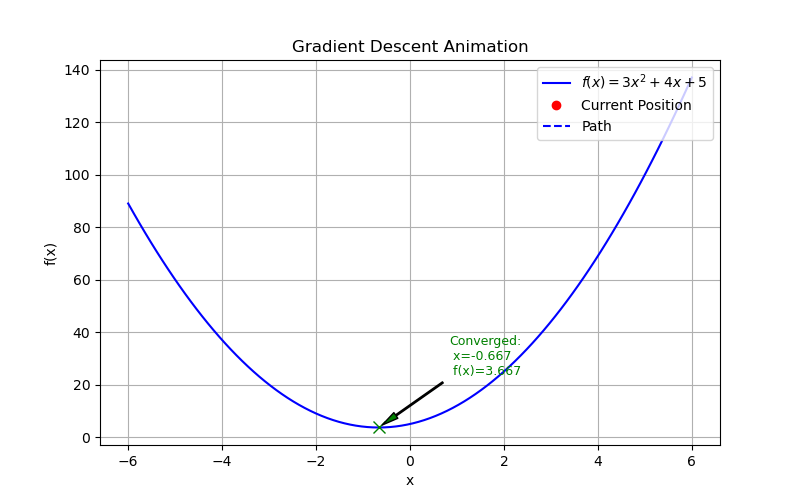

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib widget

# Define the function and its derivative
def f(x):
    """Quadratic function: f(x) = 3x^2 + 4x + 5"""
    return 3*x**2 + 4*x + 5

def df(x):
    """Derivative of f(x): df/dx = 6x + 4"""
    return 6*x + 4

# Generalized gradient descent function
def gradient_descent(f, df, x_start, learning_rate, iterations):
    """Perform gradient descent on function f with derivative df."""
    if learning_rate <= 0:
        raise ValueError("Learning rate must be positive")
    if iterations < 1:
        raise ValueError("Number of iterations must be at least 1")
    
    steps = [x_start]
    x = x_start
    for _ in range(iterations):
        gradient = df(x)
        if np.isnan(gradient):
            raise ValueError("Gradient computation returned NaN")
        x = x - learning_rate * gradient
        steps.append(x)
    return steps

# Parameters
x_start = 5
learning_rate = 0.1
iterations = 20

# Run gradient descent
steps = gradient_descent(f, df, x_start, learning_rate, iterations)

# Set up plot
fig, ax = plt.subplots(figsize=(8, 5))
x_plot_vals = np.linspace(-6, 6, 100)
ax.plot(x_plot_vals, f(x_plot_vals), label='$f(x) = 3x^2 + 4x + 5$', color='blue')
point, = ax.plot([], [], 'ro', label='Current Position')
trace, = ax.plot([], [], 'b--', label='Path')  # Trace of the path
coord_text = ax.text(0.05, 0.9, '', transform=ax.transAxes, fontsize=9)

# Plot settings
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Gradient Descent Animation')
ax.grid(True)
ax.legend(loc='upper right')

# Animation function
def update(frame):
    current_x = steps[frame]
    current_y = f(current_x)
    point.set_data([current_x], [current_y])
    trace.set_data(steps[:frame+1], [f(x) for x in steps[:frame+1]])
    coord_text.set_text(f'Step {frame}: x={current_x:.3f}, f(x)={current_y:.3f}')
    return point, trace, coord_text

# Add final point annotation
final_x, final_y = steps[-1], f(steps[-1])
ax.plot(final_x, final_y, 'gx', markersize=8)
ax.annotate(f'Converged:\n x={final_x:.3f}\n f(x)={final_y:.3f}',
            xy=(final_x, final_y), xytext=(final_x + 1.5, final_y + 20),
            arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
            fontsize=9, color='green')

# Create animation
ani = FuncAnimation(fig, update, frames=range(len(steps)), interval=1000, blit=True, repeat=False)
plt.show()

#Gradient descent and neural network

In neural network, after an iteration, the outcome may deviate the real situation(if they match too closely, then overfitting should be concerned), and the error will apppear. Here, we want to neural network to do some adjustments, so it can learn from this epoch, and do better in next time. We quote loss function to describe these errors. Let's go through MSE as an example.

A simple linear neural: $$ y_p = w*x + b $$ y_p:the predicted value x: input value w,b:paraneters

The MSE of this neural:$$ L = \frac{1}{n} \sum_{i=0}^{n} (y_t - (w \cdot x + b))^2 $$ y_t:the true value 

We want to update parameters, so lets find the gradient of w and b:
$$
\frac{dL}{dw} = \frac{1}{n} \sum_{i=0}^{n} 2 (y_t - (w \cdot x + b)) (-x) = -\frac{2}{n} \sum_{i=0}^{n} x (y_t - y_p)
$$

$$
\frac{dL}{db} = \frac{1}{n} \sum_{i=0}^{n} 2 (y_t - (w \cdot x + b)) (-1) = -\frac{2}{n} \sum_{i=0}^{n} (y_t - y_p)
$$
​
After that, we can set learning rate (η) and do update:
$$
w' = w - η * (\frac{-2}{n} \sum_{i=0}^{n} x*(y_t - y_p))
$$

$$
b' = b - η * (\frac{-2}{n} \sum_{i=0}^{n} (y_t - y_p))
$$

The next iteration will use w_new and b_new as parameters.


